In [1]:
# ============================================================
# WEEK 3 — Imbalanced Classification & LightGBM Modeling
# Project: Contextual Predictive Maintenance
# Intern Branch: preeti-dev
# Infotact Solutions
# ============================================================
 
 
# ── CELL 1: Install & Import Libraries ───────────────────
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
for lib in ["pandas", "numpy", "matplotlib", "seaborn",
            "scikit-learn", "lightgbm", "imbalanced-learn"]:
    install(lib)
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
 
# LightGBM — the main model for this week
import lightgbm as lgb
 
# SMOTE — handles class imbalance by creating synthetic failure samples
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
 
# Cross-validation and metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             average_precision_score)
 
print("✅ All libraries imported successfully")
print(f"   LightGBM version : {lgb.__version__}")

✅ All libraries imported successfully
   LightGBM version : 4.6.0


In [2]:
# ── CELL 2: Create Folder Structure ──────────────────────
for folder in ['../data/raw', '../data/processed', '../reports']:
    os.makedirs(folder, exist_ok=True)
 
print("✅ Folder structure ready")

✅ Folder structure ready


In [3]:
#── CELL 3: Load Week 2 Fused Dataset ────────────────────
df = pd.read_csv('../data/processed/week2_fused_features.csv')
 
print(f"✅ Week 2 fused dataset loaded")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print()
print(f"   Failure records    : {df['Machine failure'].sum()}")
print(f"   No Failure records : {(df['Machine failure']==0).sum()}")
print(f"   Failure rate       : {df['Machine failure'].mean()*100:.2f}%")

✅ Week 2 fused dataset loaded
   Rows    : 10000
   Columns : 35

   Failure records    : 339
   No Failure records : 9661
   Failure rate       : 3.39%


In [4]:
# ── CELL 4: Define Feature Set & Target ──────────────────
# Drop non-feature columns
drop_cols = ['UDI', 'Product ID', 'Type', 'timestamp',
             'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
 
# Keep only columns that exist in the dataframe
drop_cols = [c for c in drop_cols if c in df.columns]
 
feature_cols = [c for c in df.columns if c not in drop_cols]
target       = 'Machine failure'
 
X = df[feature_cols]
y = df[target]
 
print(f"✅ Features and target defined")
print(f"   Total features : {len(feature_cols)}")
print(f"   Target column  : {target}")
print()
print("Feature list:")
for f in feature_cols:
    print(f"   {f}")

✅ Features and target defined
   Total features : 25
   Target column  : Machine failure

Feature list:
   Air temperature [K]
   Process temperature [K]
   Rotational speed [rpm]
   Torque [Nm]
   Tool wear [min]
   Air_temperature_K_roll_mean
   Air_temperature_K_roll_std
   Air_temperature_K_roll_var
   Process_temperature_K_roll_mean
   Process_temperature_K_roll_std
   Process_temperature_K_roll_var
   Rotational_speed_rpm_roll_mean
   Rotational_speed_rpm_roll_std
   Rotational_speed_rpm_roll_var
   Torque_Nm_roll_mean
   Torque_Nm_roll_std
   Torque_Nm_roll_var
   Tool_wear_min_roll_mean
   Tool_wear_min_roll_std
   Tool_wear_min_roll_var
   ambient_temperature_C
   factory_load_density
   temp_gap
   load_torque_interaction
   heat_stress_index


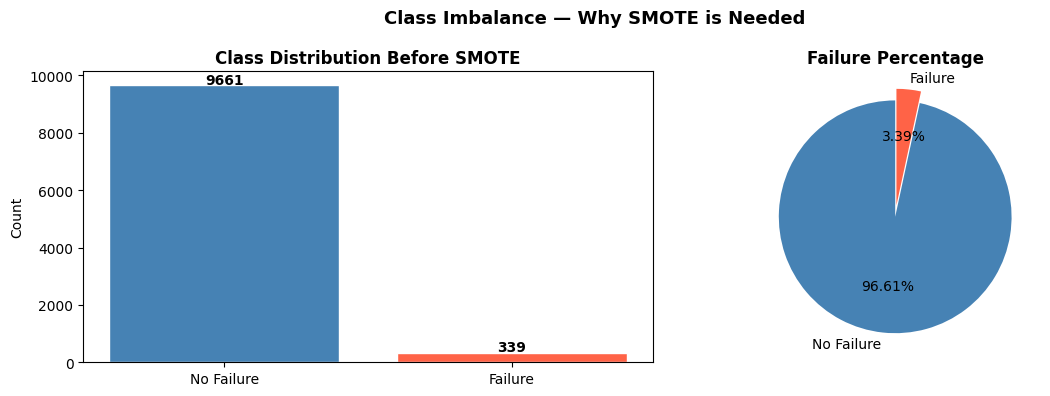

✅ Saved → reports/class_imbalance_before_smote.png


In [5]:
# ── CELL 5: Understand Class Imbalance ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Count plot
counts = y.value_counts()
axes[0].bar(['No Failure', 'Failure'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
 
# Pie chart
axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            colors=['steelblue', 'tomato'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Failure Percentage', fontweight='bold')
 
plt.suptitle('Class Imbalance — Why SMOTE is Needed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/class_imbalance_before_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/class_imbalance_before_smote.png")

In [ ]:
# ── CELL 6: What SMOTE Does (Visualization) ──────────────
# Show a quick example of what SMOTE does to class balance
# using a small sample — just for understanding
 
smote_demo = SMOTE(random_state=42)
X_demo, y_demo = smote_demo.fit_resample(X, y)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Before SMOTE
before = y.value_counts()
axes[0].bar(['No Failure', 'Failure'], before.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
 
# After SMOTE
after = pd.Series(y_demo).value_counts()
axes[1].bar(['No Failure', 'Failure'], after.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('After SMOTE (Balanced)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')
 
plt.suptitle('SMOTE Effect — Synthetic Failure Samples Created',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/smote_effect.png")
print()
print(f"   Before SMOTE — Failure: {before[1]}  |  No Failure: {before[0]}")
print(f"   After SMOTE  — Failure: {after[1]}   |  No Failure: {after[0]}")